In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

from utils import *
from plot import *


/home/karanjot/.conda/envs/sae/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
paths = [
    "./run_2-10_pythia-160m_standard_top_k/instruct/resid_post_layer_6",
    "./run_2-12_pythia-160m_standard_top_k/instruct/resid_post_layer_6",
    "./run_2-14_pythia-160m_standard_top_k/instruct/resid_post_layer_6"
]

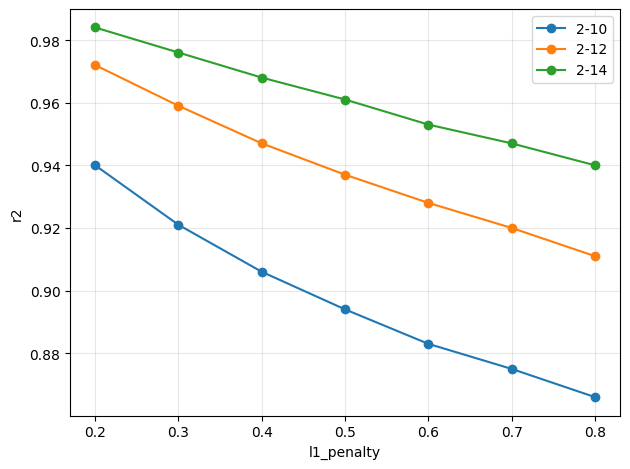

In [5]:
r_dict = collect_trainers(paths, t_class="StandardTrainer", x_k="l1_penalty", y_k="r2")
plot_line(r_dict, x_k="l1_penalty", y_k="r2")


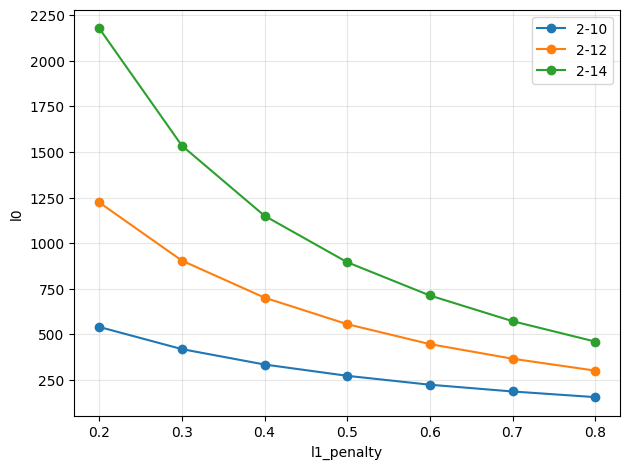

In [6]:
r_dict = collect_trainers(paths, t_class="StandardTrainer", x_k="l1_penalty", y_k="l0")
plot_line(r_dict, x_k="l1_penalty", y_k="l0")

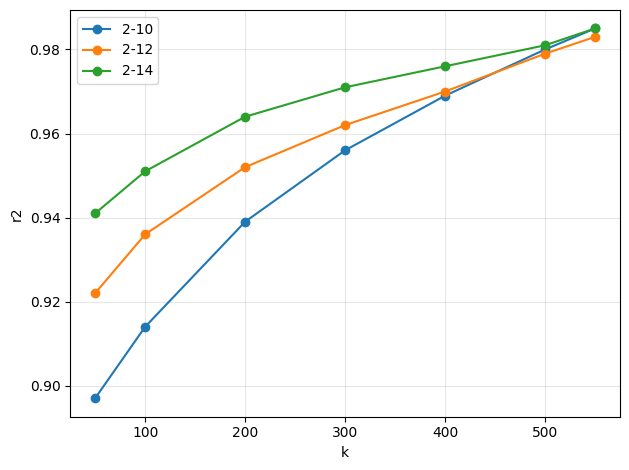

In [7]:
r_dict = collect_trainers(paths, t_class="TopKTrainer", x_k="k", y_k="r2")
plot_line(r_dict, x_k="k", y_k="r2")


In [8]:
from dictionary_learning import AutoEncoder, utils

relu_sae = AutoEncoder.from_pretrained("./run_2-10_pythia-160m_standard_top_k/instruct/resid_post_layer_6/trainer_4/ae.pt")

In [12]:
a = 100
b = 800

thr = 0.2

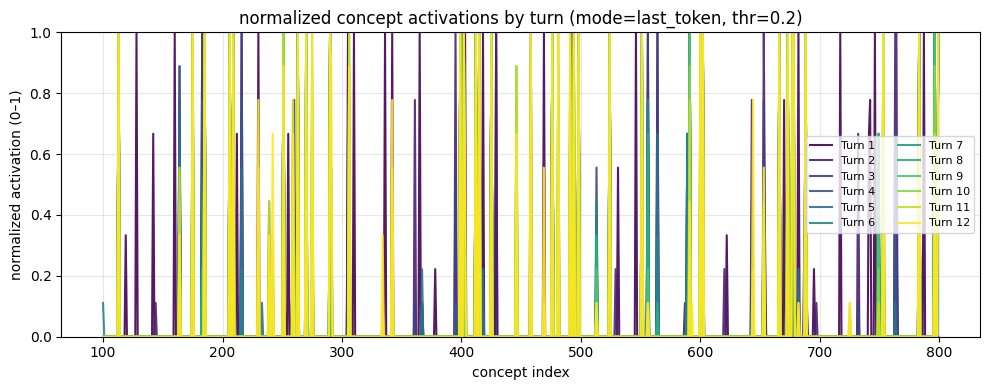

In [ ]:
conversations = get_conversations(task="prioritization", outcome="success", num_conversations=9, num_turns=12)

# topk_sae = AutoEncoder.from_pretrained("./run_2-14_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_15/ae.pt")
plot_concept_activation_count_by_turn(conversations, relu_sae, model, tokenizer, a=a, b=b, mode="last_token", plot_mode="all", threshold=thr, device=DEVICE)

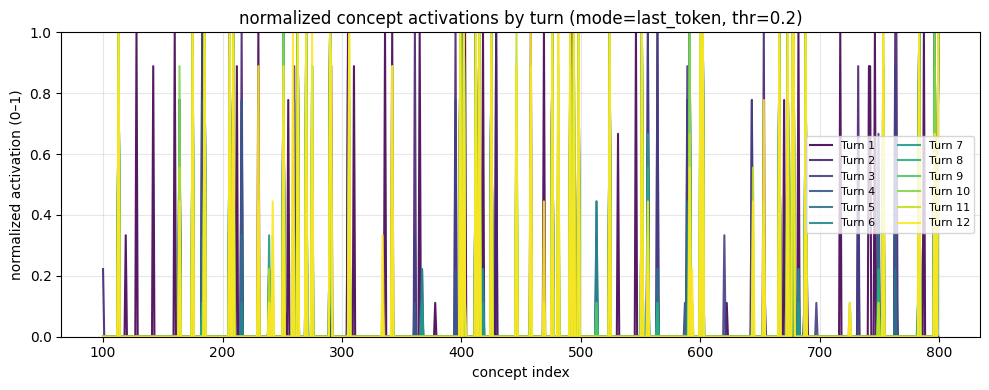

In [ ]:
conversations = get_conversations(task="prioritization", outcome="fail", num_conversations=9, num_turns=12)

plot_concept_activation_count_by_turn(conversations, relu_sae, model, tokenizer, a=a, b=b, mode="last_token", plot_mode="all", threshold=thr, device=DEVICE)